In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
historical = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

In [3]:
print(historical.head())
print(fear.head())

print(historical.shape)
print(fear.shape)

print(historical.info())
print(fear.info())

print(historical.describe(include="all"))
print(fear.describe(include="all"))

print(historical.isnull().sum())
print(fear.isnull().sum())

print("Duplicates :", historical.duplicated().sum())
print("Duplicates :", fear.duplicated().sum())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
historical = historical.drop_duplicates()
fear = fear.drop_duplicates()

historical = historical.dropna()
fear = fear.dropna()

In [5]:
historical["Date"] = pd.to_datetime(historical["Timestamp"], unit="ms").dt.date
fear["date"] = pd.to_datetime(fear["date"]).dt.date

In [6]:
merged = pd.merge(
    historical,
    fear,
    left_on="Date",
    right_on="date",
    how="left"
)

print("Merged Dataset Shape:", merged.shape)

print(merged.head())

Merged Dataset Shape: (211224, 21)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     

In [7]:
print(merged["Closed PnL"].describe())

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


In [8]:
print(merged.groupby("classification")["Closed PnL"].mean())

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


In [9]:
print(merged["classification"].value_counts())

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


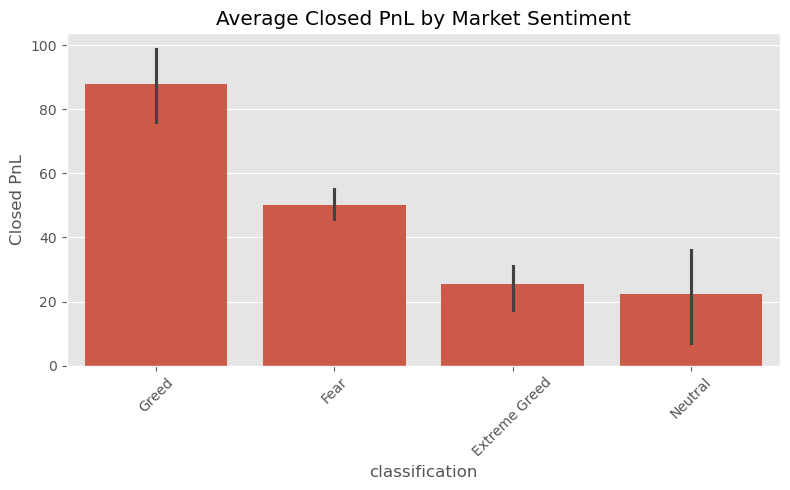

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

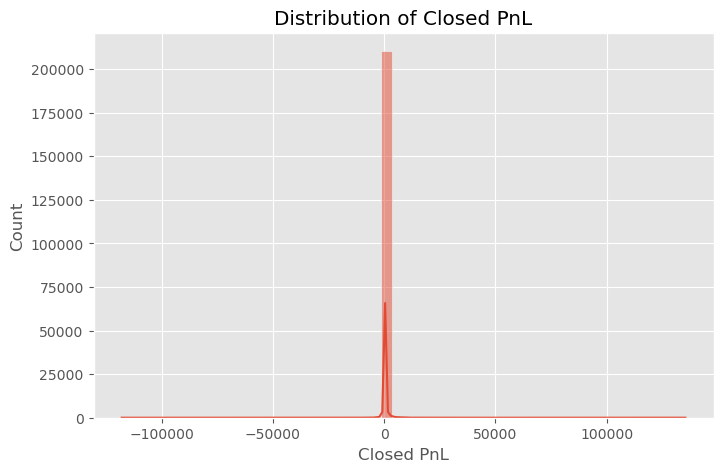

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

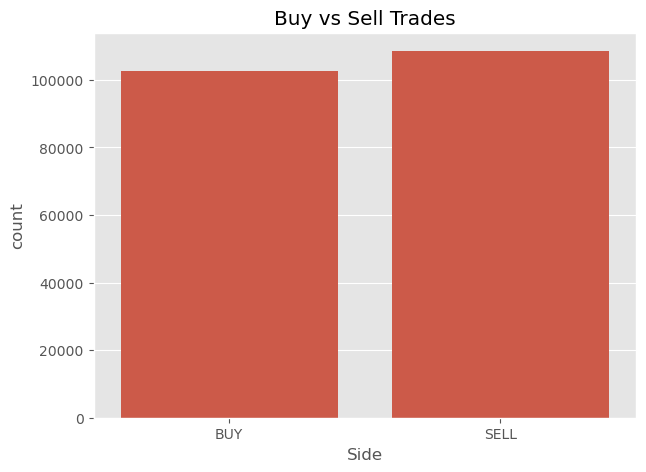

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged,
    x="Side"
)

plt.title("Buy vs Sell Trades")

plt.show()

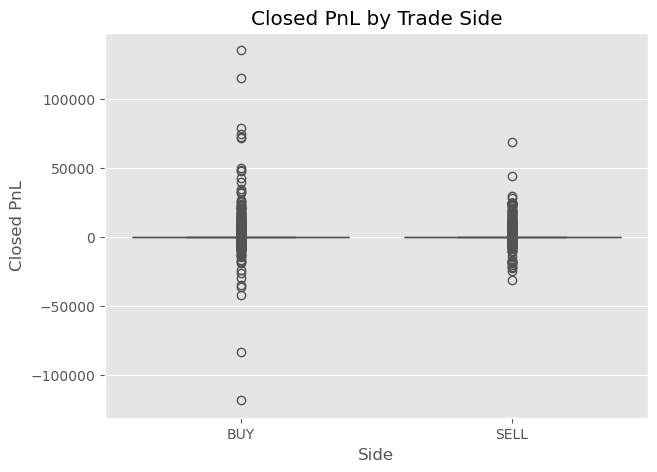

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=merged,
    x="Side",
    y="Closed PnL"
)

plt.title("Closed PnL by Trade Side")

plt.show()

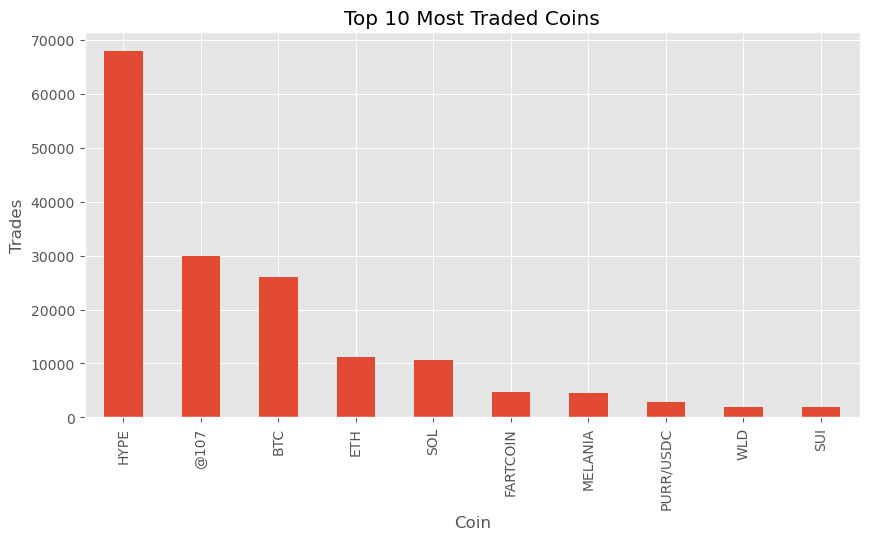

In [14]:
plt.figure(figsize=(10,5))

merged["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")

plt.ylabel("Trades")

plt.show()

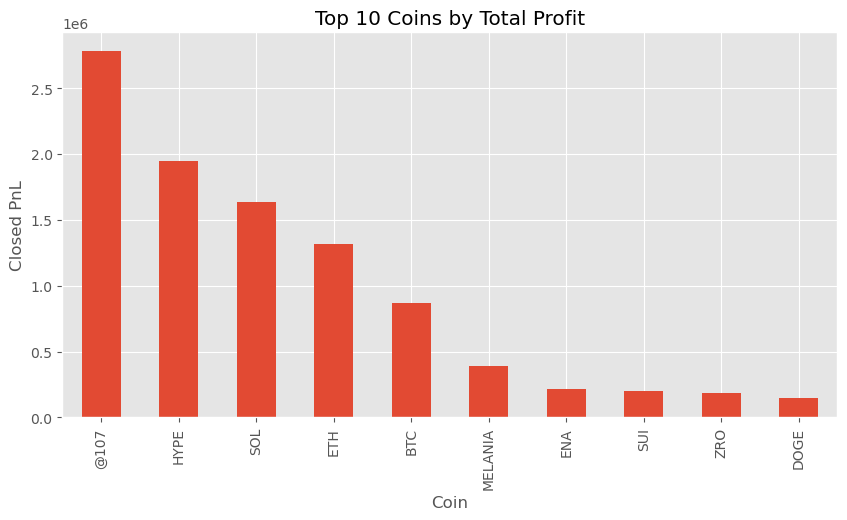

In [15]:
coin_profit = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

coin_profit.plot(kind="bar")

plt.title("Top 10 Coins by Total Profit")

plt.ylabel("Closed PnL")

plt.show()

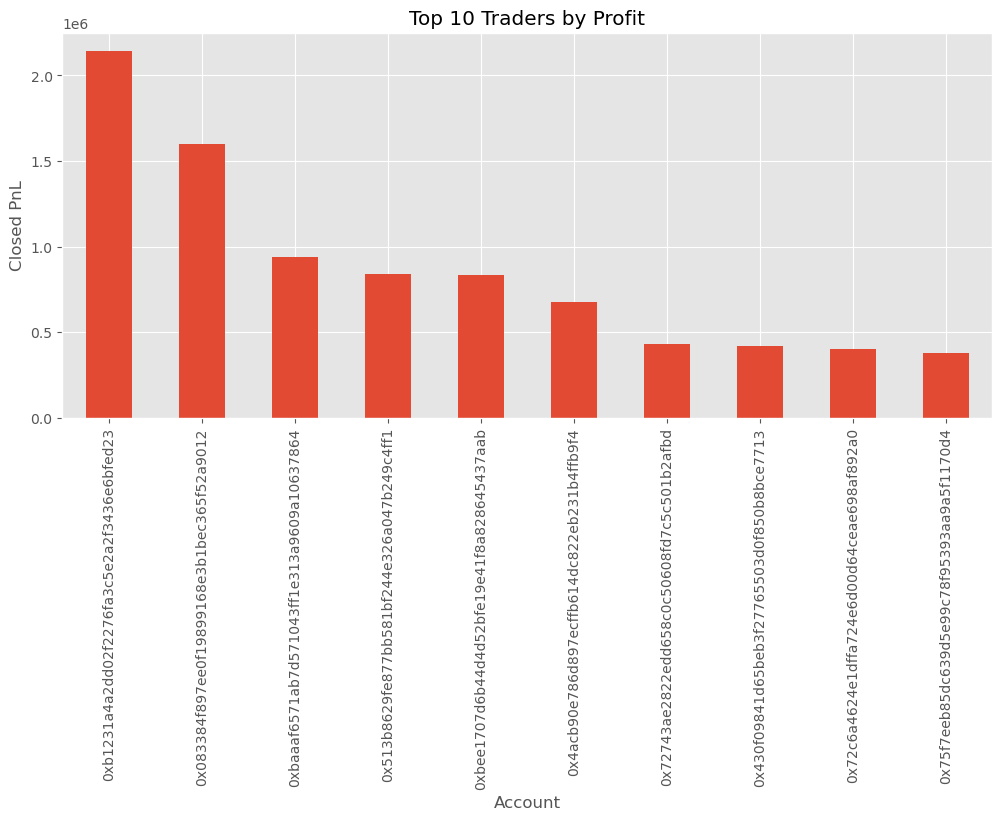

In [16]:
top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Profit")

plt.ylabel("Closed PnL")

plt.show()

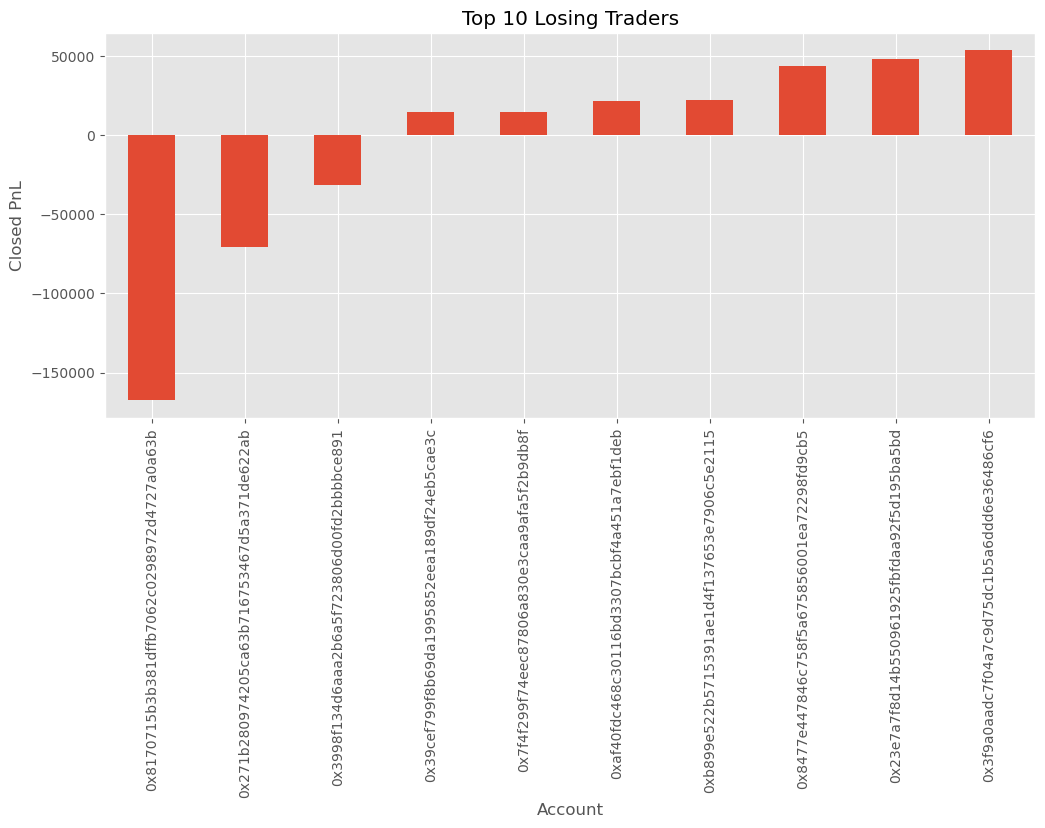

In [17]:
loss_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,5))

loss_traders.plot(kind="bar")

plt.title("Top 10 Losing Traders")

plt.ylabel("Closed PnL")

plt.show()

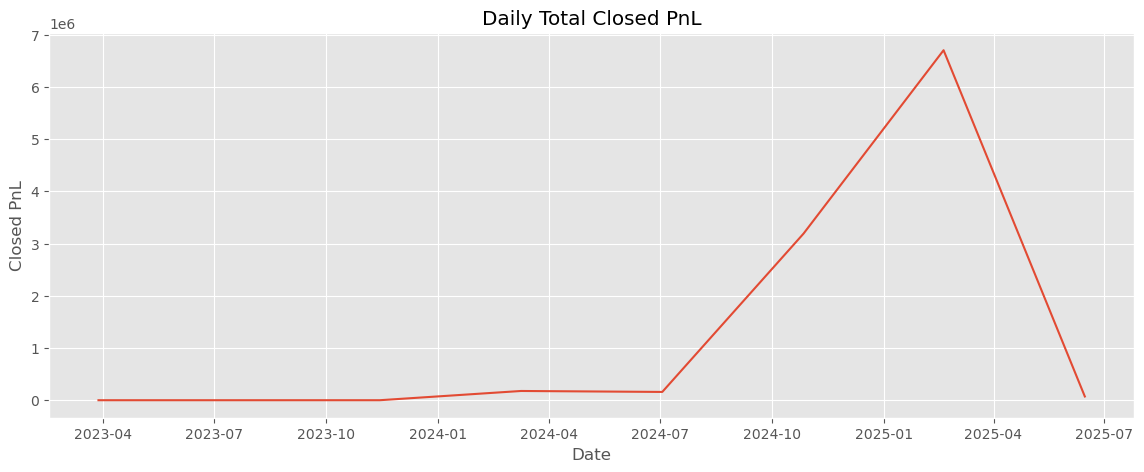

In [18]:
daily = (
    merged.groupby("Date")["Closed PnL"]
    .sum()
)

plt.figure(figsize=(14,5))

daily.plot()

plt.title("Daily Total Closed PnL")

plt.ylabel("Closed PnL")

plt.show()

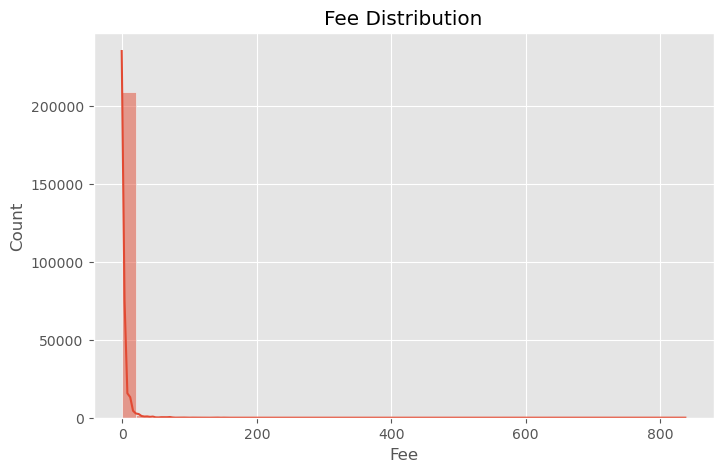

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged["Fee"],
    bins=40,
    kde=True
)

plt.title("Fee Distribution")

plt.show()

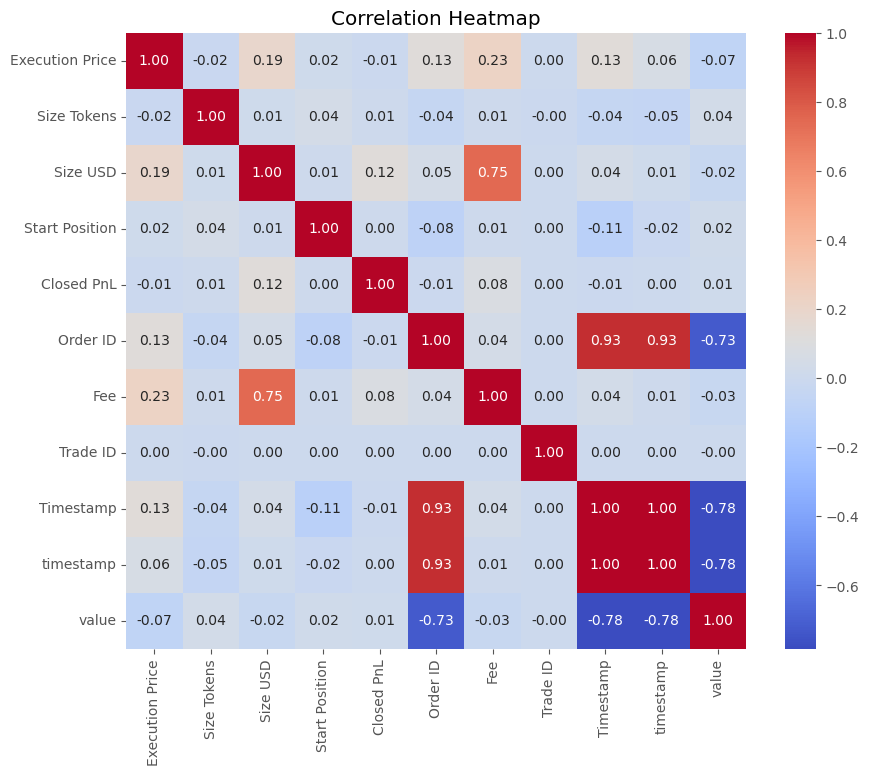

In [20]:
numeric = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

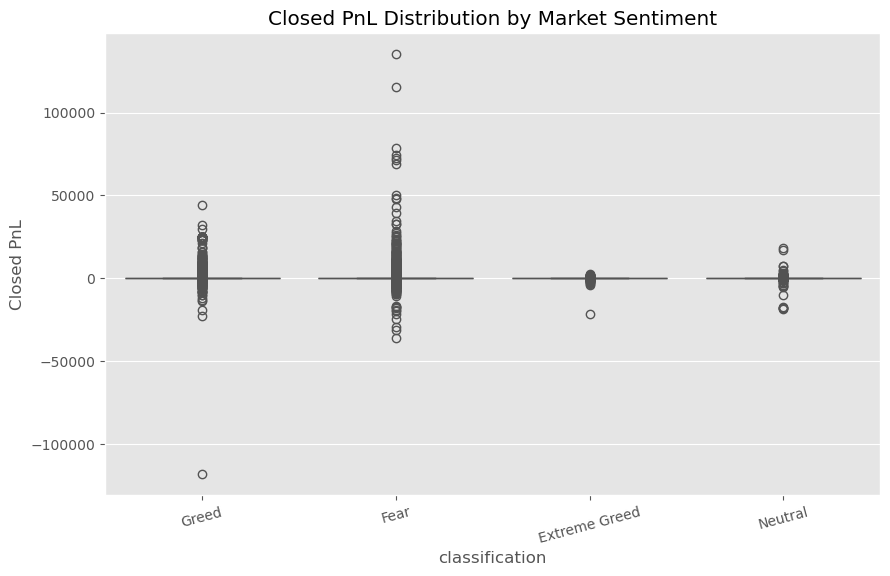

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="classification", y="Closed PnL")
plt.title("Closed PnL Distribution by Market Sentiment")
plt.xticks(rotation=15)
plt.show()

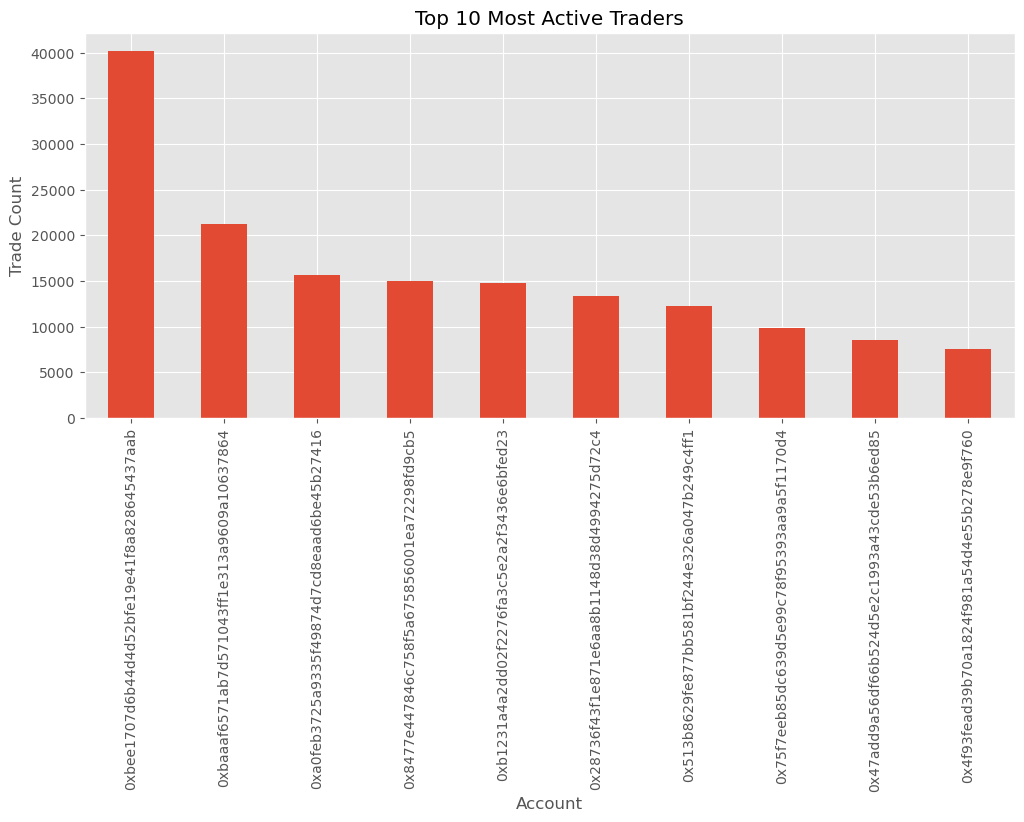

In [22]:
active = merged["Account"].value_counts().head(10)

plt.figure(figsize=(12,5))
active.plot(kind="bar")
plt.title("Top 10 Most Active Traders")
plt.ylabel("Trade Count")
plt.show()

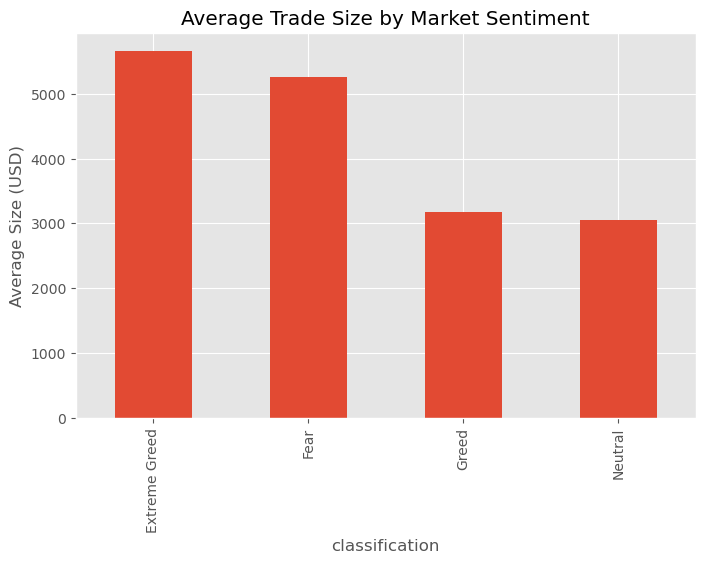

In [23]:
trade_size = merged.groupby("classification")["Size USD"].mean()

plt.figure(figsize=(8,5))
trade_size.plot(kind="bar")
plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.show()

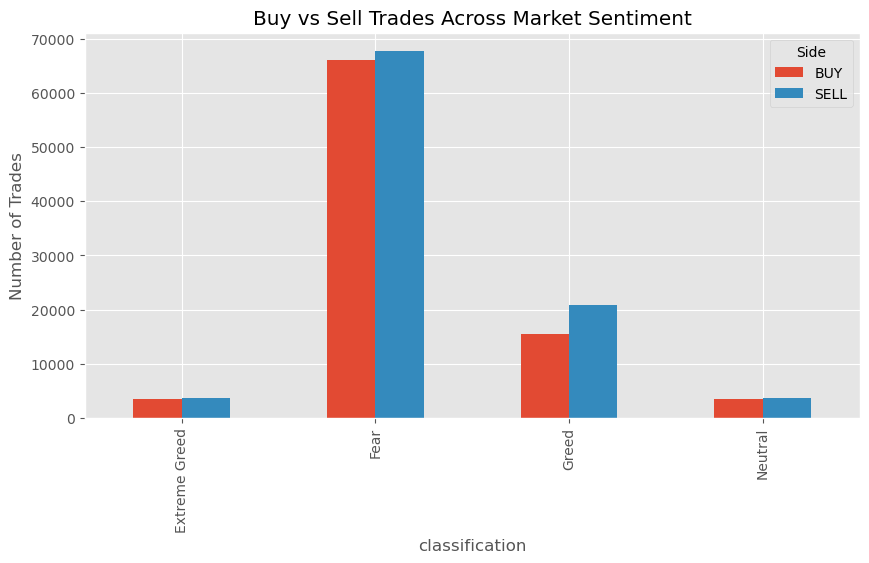

In [24]:
buy_sell = pd.crosstab(merged["classification"], merged["Side"])

buy_sell.plot(kind="bar", figsize=(10,5))

plt.title("Buy vs Sell Trades Across Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

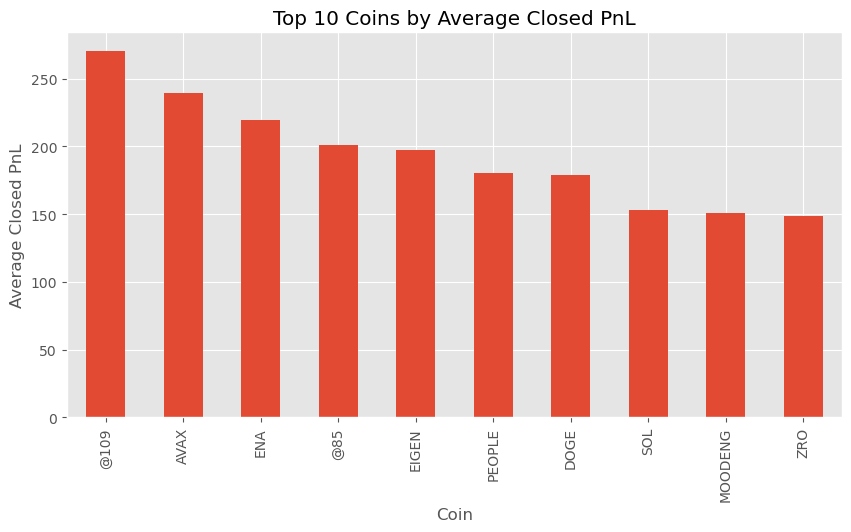

In [25]:
avg_coin = (
    merged.groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_coin.plot(kind="bar")

plt.title("Top 10 Coins by Average Closed PnL")
plt.ylabel("Average Closed PnL")
plt.show()

In [26]:
summary = merged.groupby("classification").agg(
    Total_Trades=("Closed PnL","count"),
    Avg_PnL=("Closed PnL","mean"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Fee=("Fee","mean"),
    Avg_Size_USD=("Size USD","mean")
)

print(summary)

                Total_Trades    Avg_PnL     Total_PnL   Avg_Fee  Avg_Size_USD
classification                                                               
Extreme Greed           6962  25.418772  1.769655e+05  0.978567   5660.265764
Fear                  133871  50.047622  6.699925e+06  1.083267   5259.977837
Greed                  36289  87.894859  3.189617e+06  0.670562   3182.883845
Neutral                 7141  22.229713  1.587424e+05  1.224461   3058.848110


In [27]:
print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
1. Market sentiment influences trader performance.
2. Profitability differs between Fear and Greed periods.
3. Trading activity varies across market sentiment.
4. Certain coins dominate trading volume.
5. Top traders consistently outperform others.
6. Trade size and fees show relationships with profitability.
7. These insights can support better trading strategies.
""")

PROJECT CONCLUSION

1. Market sentiment influences trader performance.
2. Profitability differs between Fear and Greed periods.
3. Trading activity varies across market sentiment.
4. Certain coins dominate trading volume.
5. Top traders consistently outperform others.
6. Trade size and fees show relationships with profitability.
7. These insights can support better trading strategies.



In [28]:
merged.to_csv("merged_trading_sentiment.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!


In [29]:
print("="*60)
print("Assignment Completed Successfully")
print("="*60)

Assignment Completed Successfully
